In [4]:
import os
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

Using device: mps


In [5]:
# ============================================
# LOAD TRAINED CARDIOVISION MODEL
# ============================================

MODEL_PATH = Path("../models/efficientnet_b0_improved_best.pt")

weights = models.EfficientNet_B0_Weights.DEFAULT

model = models.efficientnet_b0(weights=weights)

# Recreate the classifier architecture used during training
in_features = model.classifier[1].in_features

model.classifier[1] = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features, 2)
)

# Load trained checkpoint
checkpoint = torch.load(
    MODEL_PATH,
    map_location=device,
    weights_only=False
)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model = model.to(device)
model.eval()

print("Model loaded successfully.")
print("Architecture: EfficientNet-B0")
print("Checkpoint:", MODEL_PATH)

Model loaded successfully.
Architecture: EfficientNet-B0
Checkpoint: ../models/efficientnet_b0_improved_best.pt


In [6]:
# ============================================================
# LOAD DATASET METADATA
# ============================================================

DATASET_DIR = Path(
    "../data/raw/china_fundus_cimt/"
    "Fundus_CIMT_2903 Dataset"
)

JSON_PATH = DATASET_DIR / "data_info.json"

with open(JSON_PATH, "r") as f:
    metadata = json.load(f)

records = []

for patient_id, info in metadata.items():
    records.append({
        "patient_id": patient_id,
        "label": int(info["label"]),
        "age": int(info["True_age"]),
        "gender": int(info["gender"]),
        "left_eye": info["left_eye"],
        "right_eye": info["right_eye"]
    })

df = pd.DataFrame(records)

print("Dataset loaded successfully.")
print("Total patients:", len(df))
print("\nClass distribution:")
print(df["label"].value_counts())

Dataset loaded successfully.
Total patients: 2903

Class distribution:
label
1    2054
0     849
Name: count, dtype: int64


In [7]:
# ============================================================
# IMAGE PREPROCESSING
# ============================================================

IMG_SIZE = 224

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Image preprocessing ready.")

Image preprocessing ready.


In [8]:
# ============================================================
# SELECT A FUNDUS IMAGE
# ============================================================

sample = df.iloc[0]

image_path = DATASET_DIR / sample["right_eye"]

image = Image.open(image_path).convert("RGB")

print("Patient ID :", sample["patient_id"])
print("Label      :", sample["label"])
print("Age        :", sample["age"])
print("Image      :", image_path)
print("Image Size :", image.size)

Patient ID : 2491006
Label      : 0
Age        : 63
Image      : ../data/raw/china_fundus_cimt/Fundus_CIMT_2903 Dataset/2491006_R.png
Image Size : (512, 512)


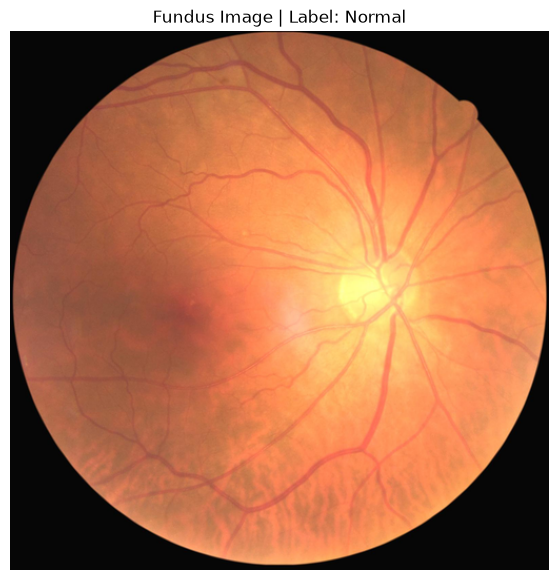

In [9]:
# ============================================================
# DISPLAY FUNDUS IMAGE
# ============================================================

plt.figure(figsize=(7, 7))
plt.imshow(image)
plt.axis("off")
plt.title(
    f"Fundus Image | Label: "
    f"{'Abnormal' if sample['label'] == 1 else 'Normal'}"
)
plt.show()

In [10]:
# ============================================================
# MODEL PREDICTION
# ============================================================

model.eval()

input_tensor = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(input_tensor)
    probabilities = torch.softmax(output, dim=1)

predicted_class = probabilities.argmax(dim=1).item()
abnormal_probability = probabilities[0, 1].item()

class_names = ["Normal", "Abnormal"]

print("=" * 50)
print("MODEL PREDICTION")
print("=" * 50)

print("Actual Label      :", class_names[sample["label"]])
print("Predicted Label   :", class_names[predicted_class])
print(f"Abnormal Probability : {abnormal_probability:.4f}")
print(f"Confidence        : {probabilities.max().item():.4f}")

MODEL PREDICTION
Actual Label      : Normal
Predicted Label   : Abnormal
Abnormal Probability : 0.6671
Confidence        : 0.6671


In [11]:
# ============================================================
# GRAD-CAM
# ============================================================

import torch.nn.functional as F

# Target layer: final convolutional block of EfficientNet-B0
target_layer = model.features[-1]

activations = None
gradients = None


def forward_hook(module, input, output):
    global activations
    activations = output


def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]


forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)


# Forward pass
model.zero_grad()

output = model(input_tensor)
predicted_class = output.argmax(dim=1).item()

# Backpropagate predicted class
score = output[0, predicted_class]
score.backward()

# Remove hooks
forward_handle.remove()
backward_handle.remove()


# Calculate Grad-CAM
weights = gradients.mean(dim=(2, 3), keepdim=True)

cam = (weights * activations).sum(dim=1, keepdim=True)

cam = F.relu(cam)

cam = F.interpolate(
    cam,
    size=(IMG_SIZE, IMG_SIZE),
    mode="bilinear",
    align_corners=False
)

cam = cam.squeeze().detach().cpu().numpy()

# Normalize
cam = cam - cam.min()

if cam.max() > 0:
    cam = cam / cam.max()

print("Grad-CAM generated successfully.")
print("Explaining:", class_names[predicted_class])

Grad-CAM generated successfully.
Explaining: Abnormal


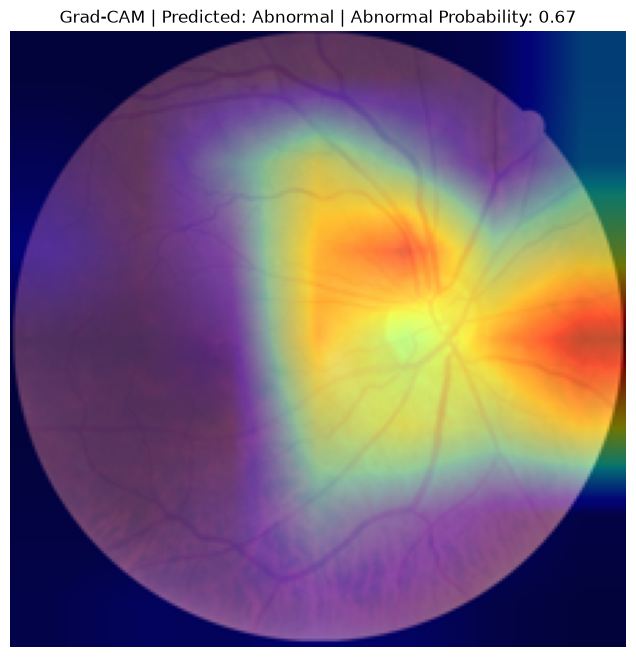

In [12]:
# ============================================================
# GRAD-CAM HEATMAP OVERLAY
# ============================================================

import matplotlib.cm as cm

# Resize original image to model size
original_image = image.resize((IMG_SIZE, IMG_SIZE))

# Convert image to numpy
original_np = np.array(original_image) / 255.0

# Create heatmap
heatmap = cm.jet(cam)[:, :, :3]

# Blend original image + Grad-CAM
overlay = (0.55 * original_np + 0.45 * heatmap)

# Normalize for display
overlay = np.clip(overlay, 0, 1)

# Display
plt.figure(figsize=(8, 8))

plt.imshow(overlay)
plt.axis("off")

plt.title(
    f"Grad-CAM | Predicted: {class_names[predicted_class]} "
    f"| Abnormal Probability: {abnormal_probability:.2f}"
)

plt.show()

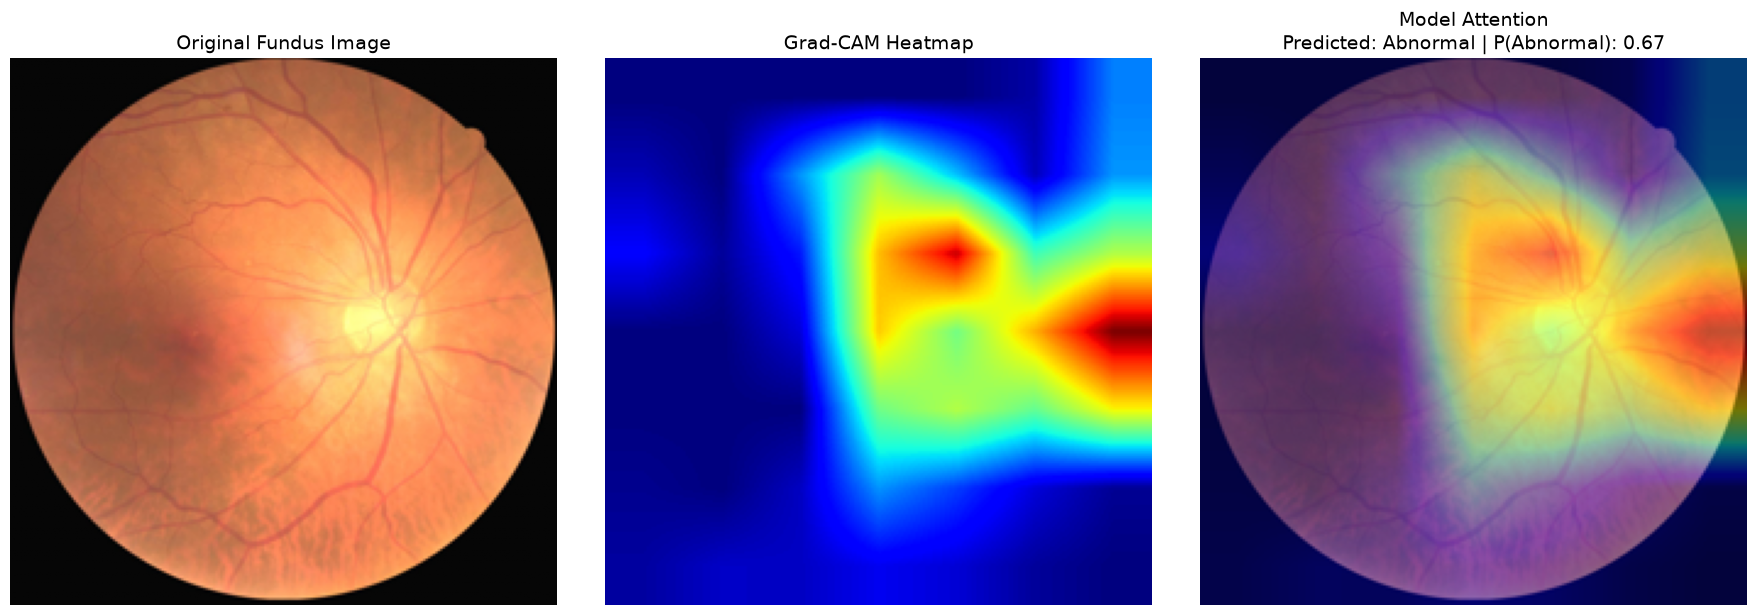

In [13]:
# ============================================================
# PROFESSIONAL GRAD-CAM VISUALIZATION
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original
axes[0].imshow(original_np)
axes[0].set_title("Original Fundus Image", fontsize=14)
axes[0].axis("off")

# Grad-CAM
axes[1].imshow(cam, cmap="jet")
axes[1].set_title("Grad-CAM Heatmap", fontsize=14)
axes[1].axis("off")

# Overlay
axes[2].imshow(overlay)
axes[2].set_title(
    f"Model Attention\n"
    f"Predicted: {class_names[predicted_class]} | "
    f"P(Abnormal): {abnormal_probability:.2f}",
    fontsize=14
)
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# RECREATE TEST DATASET FOR GRAD-CAM ANALYSIS
# ============================================================

from sklearn.model_selection import train_test_split

# Recreate the exact same patient-level split
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)


class FundusDataset(Dataset):

    def __init__(self, dataframe, dataset_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.dataset_dir = Path(dataset_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image_path = self.dataset_dir / row["right_eye"]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(
            row["label"],
            dtype=torch.long
        )

        return image, label


# Create test dataset
test_dataset = FundusDataset(
    test_df,
    DATASET_DIR,
    transform
)

print("Test dataset recreated successfully.")
print("Test samples:", len(test_dataset))
print("\nTest class distribution:")
print(test_df["label"].value_counts())

Test dataset recreated successfully.
Test samples: 291

Test class distribution:
label
1    206
0     85
Name: count, dtype: int64


In [15]:
# ============================================================
# FIND REPRESENTATIVE TEST CASES
# ============================================================

# Locked threshold selected from validation set
BEST_THRESHOLD = 0.39

model.eval()

case_indices = {
    "True Negative": None,
    "True Positive": None,
    "False Positive": None,
    "False Negative": None
}

for idx in range(len(test_dataset)):

    img_tensor, label = test_dataset[idx]

    with torch.no_grad():
        output = model(
            img_tensor.unsqueeze(0).to(device)
        )

        probability = torch.softmax(output, dim=1)[0, 1].item()

    actual = int(label)
    prediction = int(probability >= BEST_THRESHOLD)

    # Find each type of prediction
    if actual == 0 and prediction == 0:
        case_indices["True Negative"] = idx

    elif actual == 1 and prediction == 1:
        case_indices["True Positive"] = idx

    elif actual == 0 and prediction == 1:
        case_indices["False Positive"] = idx

    elif actual == 1 and prediction == 0:
        case_indices["False Negative"] = idx

    # Stop once all four cases are found
    if all(value is not None for value in case_indices.values()):
        break


print("=" * 55)
print("REPRESENTATIVE TEST CASES")
print("=" * 55)

for case, idx in case_indices.items():
    print(f"{case:18s}: Test index {idx}")

REPRESENTATIVE TEST CASES
True Negative     : Test index 8
True Positive     : Test index 13
False Positive    : Test index 14
False Negative    : Test index 6


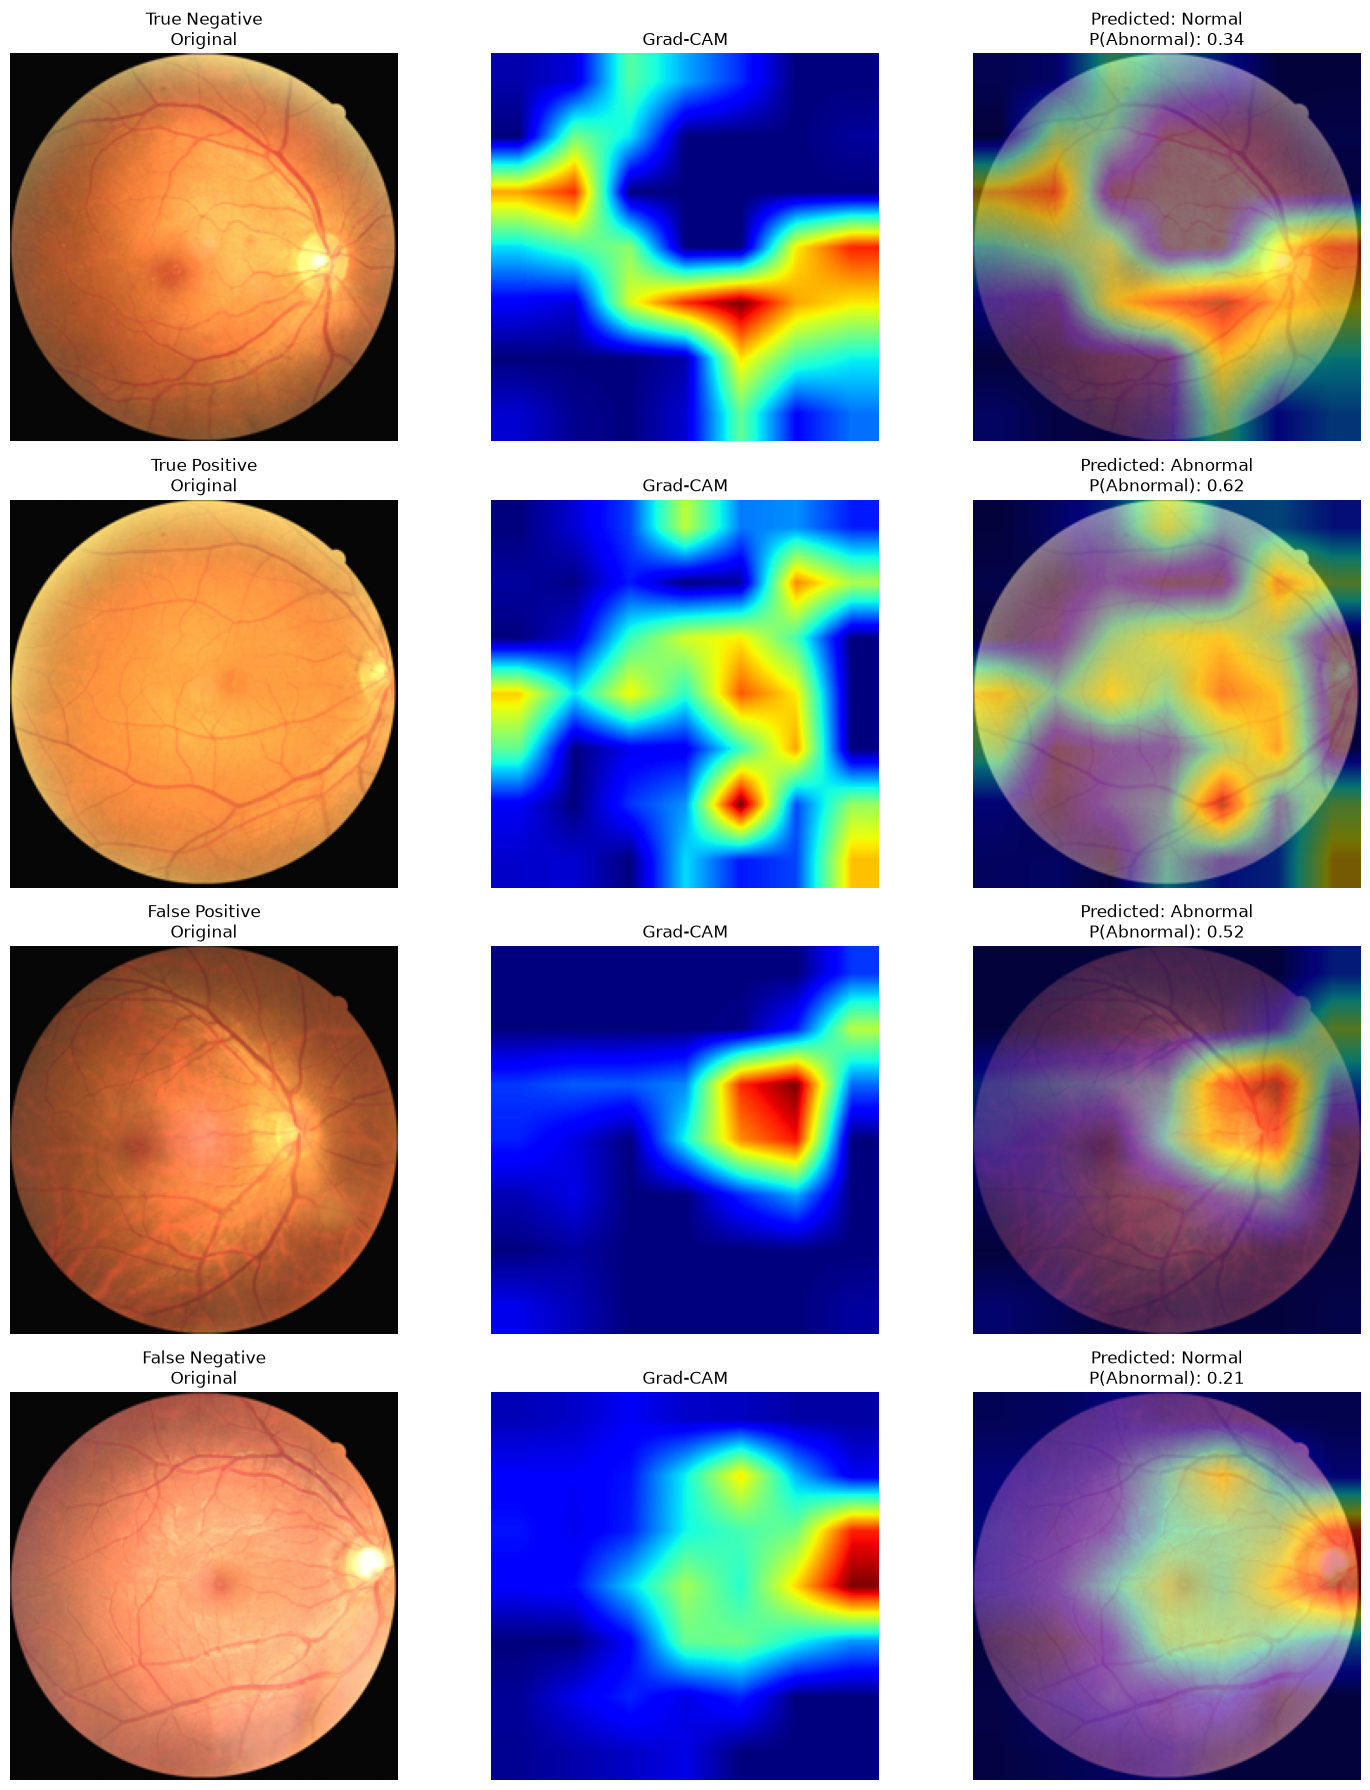

In [16]:
# ============================================================
# GRAD-CAM ERROR ANALYSIS — 4 REPRESENTATIVE CASES
# ============================================================

import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np


def generate_gradcam(model, input_tensor, target_class):
    """
    Generate Grad-CAM for EfficientNet-B0.
    """

    activations = None
    gradients = None

    target_layer = model.features[-1]

    def forward_hook(module, input, output):
        nonlocal activations
        activations = output

    def backward_hook(module, grad_input, grad_output):
        nonlocal gradients
        gradients = grad_output[0]

    forward_handle = target_layer.register_forward_hook(forward_hook)
    backward_handle = target_layer.register_full_backward_hook(backward_hook)

    model.zero_grad()

    output = model(input_tensor)
    score = output[0, target_class]
    score.backward()

    forward_handle.remove()
    backward_handle.remove()

    weights = gradients.mean(
        dim=(2, 3),
        keepdim=True
    )

    cam = (weights * activations).sum(
        dim=1,
        keepdim=True
    )

    cam = F.relu(cam)

    cam = F.interpolate(
        cam,
        size=(IMG_SIZE, IMG_SIZE),
        mode="bilinear",
        align_corners=False
    )

    cam = cam.squeeze().detach().cpu().numpy()

    cam -= cam.min()

    if cam.max() > 0:
        cam /= cam.max()

    return cam


# ============================================================
# GENERATE FIGURE
# ============================================================

fig, axes = plt.subplots(
    4, 3,
    figsize=(15, 18)
)

for row, (case_name, idx) in enumerate(case_indices.items()):

    # Load image
    img_tensor, label = test_dataset[idx]

    row_data = test_df.iloc[idx]

    image_path = DATASET_DIR / row_data["right_eye"]

    original_image = Image.open(
        image_path
    ).convert("RGB")

    original_image = original_image.resize(
        (IMG_SIZE, IMG_SIZE)
    )

    original_np = np.array(
        original_image
    ) / 255.0

    # Prepare input
    input_tensor = img_tensor.unsqueeze(0).to(device)

    # Prediction
    model.eval()

    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.softmax(
            output, dim=1
        )[0]

    predicted_class = probabilities.argmax().item()
    abnormal_probability = probabilities[1].item()

    # Grad-CAM
    cam = generate_gradcam(
        model,
        input_tensor,
        predicted_class
    )

    # Heatmap
    heatmap = plt.cm.jet(cam)[:, :, :3]

    # Overlay
    overlay = (
        0.55 * original_np +
        0.45 * heatmap
    )

    overlay = np.clip(
        overlay,
        0,
        1
    )

    # Plot original
    axes[row, 0].imshow(original_np)
    axes[row, 0].axis("off")
    axes[row, 0].set_title(
        f"{case_name}\nOriginal",
        fontsize=12
    )

    # Plot Grad-CAM
    axes[row, 1].imshow(
        cam,
        cmap="jet"
    )
    axes[row, 1].axis("off")
    axes[row, 1].set_title(
        "Grad-CAM",
        fontsize=12
    )

    # Plot overlay
    axes[row, 2].imshow(overlay)
    axes[row, 2].axis("off")

    axes[row, 2].set_title(
        f"Predicted: {class_names[predicted_class]}\n"
        f"P(Abnormal): {abnormal_probability:.2f}",
        fontsize=12
    )


plt.tight_layout()
plt.show()